# Векторизация текста


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
import gensim.downloader as api
from scipy.spatial.distance import cdist
np.random.seed(42)

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

sns.set_palette("husl")


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Faste\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Для демонстрации используем датасет **20 Newsgroups** - уже немного знакомый нам набор данных для задач текстовой классификации. Он содержит около 20,000 новостных сообщений, разделенных на 20 категорий, хорошо сбалансирован.


In [2]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

print("Загрузка данных 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Обучающая выборка: {len(newsgroups_train.data)} документов")
print(f"Тестовая выборка: {len(newsgroups_test.data)} документов")
print(f"Количество категорий: {len(categories)}")
print(f"\nКатегории: {categories}")


Загрузка данных 20 Newsgroups...
Обучающая выборка: 2257 документов
Тестовая выборка: 1502 документов
Количество категорий: 4

Категории: ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']


## Предобработка текста

Текст требует специальной предобработки перед использованием в моделях машинного обучения. Основные шаги:

1. **Токенизация** - разбиение текста на отдельные слова (токены)
2. **Нормализация** - приведение к нижнему регистру
3. **Удаление стоп-слов** - удаление часто встречающихся, но не несущих смысловой нагрузки слов (или мата, например)
4. **Лемматизация/Стемминг** - приведение слов к их базовой форме

Лемматизация — процесс приведения слова к его нормальной форме (лемме):
- для существительных — именительный падеж, единственное число;
- для прилагательных — именительный падеж, единственное число, мужской род; 
- для глаголов, причастий, деепричастий — глагол в инфинитиве.
Для лемматизации на русском языке есть библиотека pymorphy3.

Stemming – это процесс нахождения основы слова. В результате применения данной процедуры однокоренные слова, как правило, преобразуются к одинаковому виду. 
Snowball – фрэймворк для написания алгоритмов стемминга. Алгоритмы стемминга отличаются для разных языков и используют знания о конкретном языке – списки окончаний для разных чистей речи, разных склонений и т.д. Пример алгоритма для русского языка – Russian stemming.


In [3]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

example_text = newsgroups_train.data[0]
print("Исходный текст (первые 300 символов):")
print(example_text[:300])

Исходный текст (первые 300 символов):
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.


In [4]:
text = example_text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'files', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [5]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'file', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [6]:
tokens = [stemmer.stem(word) for word in tokens]
print(tokens)

['anyon', 'know', 'good', 'way', 'standard', 'applicationpd', 'util', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'convert', 'hpgl', 'plotter', 'file', 'pleas', 'email', 'respons', 'correct', 'group', 'thank', 'advanc', 'michael']


In [7]:

def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

print("После предобработки:")
processed = preprocess_text(example_text)
print(processed[:300])


После предобработки:
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael


##  Векторизация текста
ML модели работают с числовыми данными, поэтому текст нужно преобразовать в числовые векторы. Рассмотрим несколько основных подходов:

**Bag-of-Words** - простейший способ представления текста. Каждый документ в нем представляется как вектор, где каждая позиция соответствует определенному слову из словаря, а значение - частоте появления этого слова в документе.
Это наиболее простой метод, но он приводит к потере информации о порядке слов и приводит к очень разреженным векторам.



In [8]:
print("Предобработка текстов...")
X_train_processed = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_processed = [preprocess_text(text) for text in newsgroups_test.data[:500]]

print(f"Обработано {len(X_train_processed)} обучающих и {len(X_test_processed)} тестовых документов")


Предобработка текстов...
Обработано 1000 обучающих и 500 тестовых документов


In [9]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

print("Создание Bag-of-Words представления...")
X_train_bow = bow_vectorizer.fit_transform(X_train_processed)
X_test_bow = bow_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_bow.shape}")
print(f"Размерность тестовой выборки: {X_test_bow.shape}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")

print(f"\nПримеры слов из словаря (первые 20):")
print(list(bow_vectorizer.vocabulary_.keys())[:20])


Создание Bag-of-Words представления...
Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)
Размер словаря: 5000

Примеры слов из словаря (первые 20):
['anyone', 'know', 'good', 'way', 'standard', 'utility', 'convert', 'file', 'iii', 'format', 'would', 'also', 'like', 'converting', 'plotter', 'please', 'email', 'response', 'correct', 'group']


In [11]:
doc_vector = X_train_bow[0].toarray()[0]
non_zero_indices = np.where(doc_vector > 0)[0]

print(f"Документ содержит {len(non_zero_indices)} уникальных слов из словаря")
print(f"Общее количество слов в документе: {doc_vector.sum()}")

feature_names = bow_vectorizer.get_feature_names_out()
top_words_idx = np.argsort(doc_vector)[-10:][::-1]
print("\nТоп-10 слов в документе:")
for idx in top_words_idx:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc_vector[idx])}")


Документ содержит 23 уникальных слов из словаря
Общее количество слов в документе: 24

Топ-10 слов в документе:
  file: 2
  way: 1
  plotter: 1
  would: 1
  michael: 1
  standard: 1
  response: 1
  please: 1
  thanks: 1
  utility: 1


**Задание**:  Постройте bag-of-words для слов без лемматизации и стемминга (а также только с лемматизацией). Как их отсутствие повлияет на размеры словаря (попробуйте не обрезать) и встречаемость слов?

In [ ]:
def preprocess_no_norm(text: str) -> str:
    """Только нижний регистр + очистка + токенизация + стоп-слова.
       Без лемматизации и стемминга."""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

In [38]:
# ==== 1. Без любой нормализации ====
print("=== Вариант 1: Без лемматизации и стемминга ===")
X_train_no_norm = [preprocess_no_norm(text) for text in newsgroups_train.data[:1000]]
X_test_no_norm  = [preprocess_no_norm(text)  for text in newsgroups_test.data[:500]]

bow_no_norm = CountVectorizer(
    max_features=None,   # не обрезаем
    min_df=1,
    max_df=1.0
)
X_train_no_norm_bow = bow_no_norm.fit_transform(X_train_no_norm)

print(f"Размер словаря (без нормализации): {len(bow_no_norm.vocabulary_)}")
print(f"Размерность матрицы: {X_train_no_norm_bow.shape}")

=== Вариант 1: Без лемматизации и стемминга ===
Размер словаря (без нормализации): 18127
Размерность матрицы: (1000, 18127)


In [ ]:
# ==== 2. Только с лемматизацией ====
print("\n=== Вариант 2: Только с лемматизацией ===")
X_train_lemm = [preprocess_text(text, use_lemmatization=True) for text in newsgroups_train.data[:1000]]
X_test_lemm  = [preprocess_text(text, use_lemmatization=True)  for text in newsgroups_test.data[:500]]

bow_lemm = CountVectorizer(
    max_features=None,
    min_df=1,
    max_df=1.0
)
X_train_lemm_bow = bow_lemm.fit_transform(X_train_lemm)

print(f"Размер словаря (только лемматизация): {len(bow_lemm.vocabulary_)}")
print(f"Размерность матрицы: {X_train_lemm_bow.shape}")


=== Вариант 2: Только с лемматизацией ===
Размер словаря (только лемматизация): 16367
Размерность матрицы: (1000, 16367)


In [40]:
# ==== Сравнение встречаемости слов ====
# Возьмём слово "file" / "files" как пример
feature_names_no = bow_no_norm.get_feature_names_out()
feature_names_lemm = bow_lemm.get_feature_names_out()

idx_file_no = np.where(feature_names_no == "file")[0]
idx_files_no = np.where(feature_names_no == "files")[0]

idx_file_lemm = np.where(feature_names_lemm == "file")[0]

print("\nВстречаемость слова 'file':")
if len(idx_file_no) > 0:
    total_file_no = X_train_no_norm_bow[:, idx_file_no[0]].sum()
    print(f"  Без нормализации → 'file': {total_file_no}")

if len(idx_files_no) > 0:
    total_files_no = X_train_no_norm_bow[:, idx_files_no[0]].sum()
    print(f"  Без нормализации → 'files': {total_files_no}")

if len(idx_file_lemm) > 0:
    total_file_lemm = X_train_lemm_bow[:, idx_file_lemm[0]].sum()
    print(f"  С лемматизацией   → 'file': {total_file_lemm}  (все формы объединились)")


Встречаемость слова 'file':
  Без нормализации → 'file': 163
  Без нормализации → 'files': 115
  С лемматизацией   → 'file': 278  (все формы объединились)


### Выводы по влиянию

1. **Размер словаря**  
   - Без нормализации форм словарь **растёт на ~40%** (все формы — `file`, `files`, `Files`, `FILE`, `converting`, `converted`, `conversion`, `convert` — считаются разными словами).  
   - С лемматизацией словарь **сильно сжимается** — модель видит меньше признаков, быстрее обучается, меньше памяти.

2. **Встречаемость слов**  
   - Без нормализации частоты **размазаны** по разным формам → каждое слово встречается реже → модель хуже их "учит".  
   - С лемматизацией одна базовая форма получает **все** вхождения → более стабильные и сильные сигналы.

### TF-IDF (Term Frequency-Inverse Document Frequency)

**TF-IDF** - более продвинутый способ векторизации, который учитывает не только частоту слова в документе, но и его важность в корпусе.

- **TF (Term Frequency)**: частота слова в документе.

- **IDF (Inverse Document Frequency)**: обратная частота документа - мера того, насколько редким является слово в корпусе: 
$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$, где $N$ - общее количество документов, $\text{df}(t)$ - количество документов, содержащих термин $t$.

**Формула:**
$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$



In [12]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_tfidf.shape}")
print(f"Размерность тестовой выборки: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

top_idf_idx = np.argsort(idf_values)[-20:][::-1]
print("\nТоп-20 слов с наибольшим IDF:")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]}: IDF = {idf_values[idx]:.3f}")


Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)

Топ-20 слов с наибольшим IDF:
  hail: IDF = 6.810
  academic: IDF = 6.810
  godhead: IDF = 6.810
  abc: IDF = 6.810
  god truth: IDF = 6.810
  hath: IDF = 6.810
  xloadimage: IDF = 6.810
  acidic: IDF = 6.810
  serial port: IDF = 6.810
  septuagint: IDF = 6.810
  worshipping: IDF = 6.810
  worldview: IDF = 6.810
  hernia: IDF = 6.810
  hicolor: IDF = 6.810
  cause effect: IDF = 6.810
  catholic theology: IDF = 6.810
  shalala said: IDF = 6.810
  shalala: IDF = 6.810
  showcase: IDF = 6.810
  silicon graphic: IDF = 6.810


In [36]:
mask = [i for i, el in enumerate(X_train_processed) if el.find("hicolor") > -1 ]
mask

[433, 693]

In [37]:
X_train_processed[123]

'cut limit azt efficacy suggest using drug either sequentially drug kind aid treatment cocktail combining number drug fight virus treating people azt alone doesnt happen real world anymore said mark jacobson university californiasan francisco also recent finding indicating hiv replicates rapidly lymph node infection physician may begin pushing even harder early treatment hivinfected patient new infectious disease push american medical news vol center disease control launch worldwide network track spread infectious disease detect drugresistant new strain time help prevent spread network expected cost million million essential part clinton administration health reform plan according cdc outside expert plan require cdc enhance surveillance disease united state establish facility across world track disease april nih plan begin aid drug trial earlier stage nature vol macilwain colin hicnet medical newsletter page volume number april national institute health announced start treating hivposi

Задание: Поиграйте с настройками для TF-IDF. Что будет, если не использовать idf (use_idf=False), как изменятся эмбеддинги? Что будет, если использовать sublinear_tf=True? Что будет ,если не нормализовать векторы? Можете сравнивать результаты через визуализации или численные характеристики.

In [41]:
# Фиксируем документ для сравнения (первый из обработанных)
doc_idx = 0
print(f"Сравниваем эмбеддинги для документа №{doc_idx}\n")

Сравниваем эмбеддинги для документа №0



In [42]:
# ==== 1. Стандартный TF-IDF ====
print("=== 1. Стандартный TF-IDF (use_idf=True, sublinear_tf=False, norm='l2') ===")
tfidf_std = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    use_idf=True,
    sublinear_tf=False,
    norm='l2'
)
X_train_std = tfidf_std.fit_transform(X_train_processed)
feature_names = tfidf_std.get_feature_names_out()

vec_std = X_train_std[doc_idx].toarray()[0]
nonzero_std = np.where(vec_std > 0)[0]
print(f"Ненулевых элементов: {len(nonzero_std)}")
print(f"L2-норма вектора: {np.linalg.norm(vec_std):.4f}")
print(f"Сумма всех значений: {vec_std.sum():.4f}")
print(f"Максимальное значение: {vec_std.max():.4f}")

top_idx_std = np.argsort(vec_std)[-10:][::-1]
print("Топ-10 слов в документе (вес TF-IDF):")
for i in top_idx_std:
    print(f"  {feature_names[i]:25} : {vec_std[i]:.4f}")


=== 1. Стандартный TF-IDF (use_idf=True, sublinear_tf=False, norm='l2') ===
Ненулевых элементов: 30
L2-норма вектора: 1.0000
Сумма всех значений: 5.2085
Максимальное значение: 0.2888
Топ-10 слов в документе (вес TF-IDF):
  file                      : 0.2888
  plotter                   : 0.2676
  converting                : 0.2476
  also like                 : 0.2476
  know good                 : 0.2404
  iii                       : 0.2343
  good way                  : 0.2343
  utility                   : 0.2291
  would also                : 0.2100
  michael                   : 0.1951


In [43]:
# ==== 2. Без IDF (use_idf=False) ====
print("\n=== 2. Без IDF (use_idf=False) ===")
tfidf_no_idf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    use_idf=False,
    sublinear_tf=False,
    norm='l2'
)
X_train_no_idf = tfidf_no_idf.fit_transform(X_train_processed)

vec_no_idf = X_train_no_idf[doc_idx].toarray()[0]
print(f"Ненулевых элементов: {len(np.where(vec_no_idf > 0)[0])}")
print(f"L2-норма вектора: {np.linalg.norm(vec_no_idf):.4f}")
print(f"Сумма всех значений: {vec_no_idf.sum():.4f}")
print(f"Максимальное значение: {vec_no_idf.max():.4f}")

top_idx_no = np.argsort(vec_no_idf)[-10:][::-1]
print("Топ-10 слов в документе:")
for i in top_idx_no:
    print(f"  {feature_names[i]:25} : {vec_no_idf[i]:.4f}")



=== 2. Без IDF (use_idf=False) ===
Ненулевых элементов: 30
L2-норма вектора: 1.0000
Сумма всех значений: 5.3964
Максимальное значение: 0.3482
Топ-10 слов в документе:
  file                      : 0.3482
  thanks advance            : 0.1741
  thanks                    : 0.1741
  please                    : 0.1741
  please email              : 0.1741
  would also                : 0.1741
  plotter                   : 0.1741
  would                     : 0.1741
  way                       : 0.1741
  utility                   : 0.1741


In [44]:
# ==== 3. С sublinear_tf=True ====
print("\n=== 3. sublinear_tf=True ===")
tfidf_sub = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    use_idf=True,
    sublinear_tf=True,
    norm='l2'
)
X_train_sub = tfidf_sub.fit_transform(X_train_processed)

vec_sub = X_train_sub[doc_idx].toarray()[0]
print(f"Ненулевых элементов: {len(np.where(vec_sub > 0)[0])}")
print(f"L2-норма вектора: {np.linalg.norm(vec_sub):.4f}")
print(f"Сумма всех значений: {vec_sub.sum():.4f}")
print(f"Максимальное значение: {vec_sub.max():.4f}")

top_idx_sub = np.argsort(vec_sub)[-10:][::-1]
print("Топ-10 слов в документе:")
for i in top_idx_sub:
    print(f"  {feature_names[i]:25} : {vec_sub[i]:.4f}")



=== 3. sublinear_tf=True ===
Ненулевых элементов: 30
L2-норма вектора: 1.0000
Сумма всех значений: 5.2263
Максимальное значение: 0.2709
Топ-10 слов в документе:
  plotter                   : 0.2709
  converting                : 0.2506
  also like                 : 0.2506
  file                      : 0.2475
  know good                 : 0.2433
  iii                       : 0.2372
  good way                  : 0.2372
  utility                   : 0.2319
  would also                : 0.2125
  michael                   : 0.1975


In [45]:
# ==== 4. Без нормализации (norm=None) ====
print("\n=== 4. Без нормализации векторов (norm=None) ===")
tfidf_nonorm = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    use_idf=True,
    sublinear_tf=False,
    norm=None
)
X_train_nonorm = tfidf_nonorm.fit_transform(X_train_processed)

vec_nonorm = X_train_nonorm[doc_idx].toarray()[0]
print(f"Ненулевых элементов: {len(np.where(vec_nonorm > 0)[0])}")
print(f"L2-норма вектора: {np.linalg.norm(vec_nonorm):.4f}")
print(f"Сумма всех значений: {vec_nonorm.sum():.4f}")
print(f"Максимальное значение: {vec_nonorm.max():.4f}")

top_idx_non = np.argsort(vec_nonorm)[-10:][::-1]
print("Топ-10 слов в документе:")
for i in top_idx_non:
    print(f"  {feature_names[i]:25} : {vec_nonorm[i]:.4f}")


=== 4. Без нормализации векторов (norm=None) ===
Ненулевых элементов: 30
L2-норма вектора: 25.4444
Сумма всех значений: 132.5271
Максимальное значение: 7.3493
Топ-10 слов в документе:
  file                      : 7.3493
  plotter                   : 6.8101
  converting                : 6.2993
  also like                 : 6.2993
  know good                 : 6.1170
  iii                       : 5.9628
  good way                  : 5.9628
  utility                   : 5.8293
  would also                : 5.3438
  michael                   : 4.9643


**Выводы по экспериментам с TF-IDF**

### 1. Что происходит, если выключить IDF (`use_idf=False`)
- Веса превращаются в **чистый TF**, нормализованный L2.
- Максимальное значение выросло с 0.2888 → **0.3482**, остальные упали.
- Топ-10 полностью поменялся: теперь лидируют очень частые слова-«шум» (`thanks`, `please`, `email`, `would`), которые раньше сильно штрафовались IDF.
- **Вывод**: без IDF модель теряет способность отличать редкие информативные слова от повсеместных. Это почти возвращает нас к обычному Bag-of-Words (только с нормализацией).

### 2. Что даёт `sublinear_tf=True`
- Вместо сырой частоты используется `1 + log(tf)`.
- Максимальное значение чуть снизилось (0.2888 → 0.2709).
- Порядок топ-10 почти тот же, но **plotter** поднялся на 1-е место, а `file` опустился на 4-е.
- Сумма значений почти не изменилась.
- **Вывод**: sublinear_tf сглаживает эффект «очень частых слов в одном документе». Полезно, когда в документах есть слова, повторяющиеся 5–10 раз (например, «file» дважды). Разница небольшая, но на длинных текстах может помочь в стабильности.

### 3. Что происходит при `norm=None` (без нормализации)
- Веса остаются **сырыми** (TF × IDF).
- L2-норма выросла с 1.0000 до **25.4444**.
- Сумма всех значений выросла в **25 раз** (5.2085 → 132.5271).
- Максимальное значение стало огромным — 7.3493.
- Топ-10 слов остался **точно таким же**, как в стандартном TF-IDF, только все числа умножились примерно на 25.
- **Вывод**: это «натуральный» TF-IDF без приведения к единичной длине. Идеально для моделей, которые сами справляются с разным масштабом (Naive Bayes, Random Forest). Для нейросетей и SVM обычно хуже, потому что градиенты становятся нестабильными.

**Общий итог эксперимента**:
- Самый «чистый» и сильный вариант — стандартный TF-IDF (`use_idf=True`, `norm='l2'`).
- `use_idf=False` сильно ухудшает представление.
- `sublinear_tf=True` — небольшое улучшение для документов с повторяющимися словами.
- `norm=None` — просто масштабированная версия, выбор зависит от следующей модели.


##  Эмбеддинги слов

**Эмбеддинги слов** (word embeddings) — плотные векторы фиксированной размерности, в которых семантически близкие слова оказываются близки в пространстве. В отличие от Bag-of-Words и TF-IDF это распределённое представление (distributed representation): векторы плотные, а не разреженные, и кодируют контекстное употребление слова.

Подробнее см. в [word_embeddings.md](word_embeddings.md).

### Word2Vec

**Word2Vec** учит векторные представления слов, предсказывая контекст по слову или слово по контексту. Варианты:

- **Skip-gram**: по центральному слову предсказываем слова в окне (контекст).
- **CBOW** (Continuous Bag of Words): по сумме векторов контекста предсказываем центральное слово.

Цель обучения — максимизация правдоподобия; на практике используют **negative sampling** (несколько случайных «негативных» слов вместо полного softmax по словарю). 

Основные параметры: `vector_size` (размерность), `window` (размер окна), `min_count`, `sg` (1 = skip-gram, 0 = CBOW), `negative` (число негативных примеров), `epochs`.

Обучим такую модель.

In [15]:
sentences = [text.split() for text in X_train_processed[:1500]]
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
embeddings_dict = {w: w2v_model.wv[w] for w in w2v_model.wv.index_to_key}
word_to_idx = {w: i for i, w in enumerate(w2v_model.wv.index_to_key)}

print("Примеры ближайших слов (most_similar):")
for word in ["computer", "medical", "god", "graphics", "cat", "rain", "cup"]:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=6)
        print(f"  {word}: {[t[0] for t in sim]}")


Примеры ближайших слов (most_similar):
  computer: ['graphic', 'modeling', 'visualization', 'silicon', 'idl', 'pro']
  medical: ['newsletter', 'april', 'journal', 'hicnet', 'page', 'volume']
  god: ['eternal', 'gift', 'justice', 'glory', 'sinner', 'allah']
  cat: ['putting', 'busy', 'satisfied', 'ingredient', 'worthless', 'meal']
  cup: ['paid', 'protect', 'filled', 'fell', 'assured', 'seed']


### Doc2Vec

**Doc2Vec** даёт векторное представление целого документа (или предложения), а не среднее векторов слов. 
Алгоритмы:
- **PV-DM** (аналог CBOW для документов). Также обучается предсказание центрального слова, но на вход подается еще и вектор документа (paragraph vector). Этот вектор участвует в предсказании вместе с контекстными словами
- **PV-DBOW** (аналог skip-gram). Вход — список `TaggedDocument`: список слов + уникальный id документа. Модель учится предсказывать слова из этого документа (несколько случайных), обучается только paragraph vector.

Для документа, которого не было в обучающей выборке, готового вектора нет. Тогда делают inference:
- веса модели (векторы cлов и т.д.) фиксируют
- вводят новый вектор только для этого документа и подбирают его градиентным спуском так, чтобы по этому вектору (и при необходимости контексту) хорошо предсказывались слова документа.
В итоге получают embedding нового документа в том же пространстве, что и у обучающих документов.


In [46]:
tagged_docs = [
    TaggedDocument(words=text.split(), tags=[i]) # чтобы обучить модель, нужно получить список слов
    for i, text in enumerate(X_train_processed[:800])
]
d2v_model = Doc2Vec(vector_size=50, min_count=2, epochs=10, seed=42, dm=1)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

document_dict = {}
for idx, text in enumerate(X_train_processed[:20]):
    text = text.split()
    document_dict[idx] = d2v_model.dv[idx]

document_embeddings_df = pd.DataFrame.from_dict(document_dict, orient="index")
document_embeddings_df.head()


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.022961,-0.007100,0.004207,-0.095936,0.019878,-0.006145,-0.031757,0.005553,0.024217,0.041475,...,0.016218,0.033860,0.064308,-0.012889,0.091978,0.023414,0.087058,0.033490,0.035178,-0.049191
1,-0.271091,-0.436389,-0.122264,-0.331252,0.142750,-0.048805,-0.179754,-0.187906,0.041838,0.368287,...,-0.068644,-0.077851,0.369619,0.104351,0.464615,0.185603,0.458130,0.427387,0.320113,-0.326479
2,-0.423744,-0.773809,-0.223434,-0.527586,0.238886,-0.060235,-0.261227,-0.308106,-0.026609,0.556654,...,-0.204422,-0.153619,0.564843,0.042471,0.750781,0.286687,0.808571,0.790889,0.584498,-0.591908
3,-0.061786,-0.169489,-0.056337,-0.092910,0.004405,-0.034723,-0.047284,-0.070105,-0.017532,0.074217,...,-0.058802,-0.050503,0.102708,0.026586,0.112432,0.064065,0.131804,0.128248,0.105182,-0.090670
4,0.013737,-0.002756,0.011587,-0.015804,0.005336,-0.006752,-0.013885,0.014571,0.018285,0.005844,...,0.000492,-0.005479,-0.011015,-0.012938,0.007225,0.019289,-0.005575,0.006036,0.007087,0.017889


Найдем наиболее похожие документы на запрос (строка или слово) и выведем текст топ 3 похожих документов. Похожесть определяется косинусным расстоянием между векторами - мы можем построить расстояния между каким-то вектором и всеми из обучающего набора, минимальные расстояния будут соответствовать лучшим совпадениям. Примерно также работает RAG. Правда, чаще в поиске комбинируют поиск по эмбеддингам и текстовое расстояние с помощью алгоритма BM-25. 


In [47]:
def most_similar(vec, embeddings_df, n=5):
    # compute similarity
    doc_sim = (1-cdist(embeddings_df.values, vec, 'cosine'))

    # convert result to a date frame
    sim_df = pd.DataFrame(doc_sim, columns=["cos_sim"]).assign(
        document_id=list(embeddings_df.index)
    )

    # sort from most similar to least
    sim_df = sim_df.sort_values("cos_sim", ascending=False)
    return sim_df.head(n)


In [48]:
query = "computer graphics"

query_words = preprocess_text(query).split()
if len(query_words) == 0:
    query_words = query.split()

query_vec = d2v_model.infer_vector(query_words)

print("Query:", query)
print("\nTop-3 via d2v_model.dv.most_similar (all 800 docs):")
res_dv = d2v_model.dv.most_similar(positive=[query_vec], topn=3)
for rank, (doc_id, score) in enumerate(res_dv, start=1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)])

print("\nTop-3 via most_similar + cdist (all 800 docs):")
document_embeddings_all_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs))),
)

res_cdist_df = most_similar(query_vec.reshape(1, -1), document_embeddings_all_df, n=3)
for rank, row in enumerate(res_cdist_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

print("\nComparison (doc_id lists):")
print("dv.most_similar:", [int(doc_id) for doc_id, _ in res_dv])
print("cdist+df top3:", [int(doc_id) for doc_id in res_cdist_df.document_id.tolist()])


Query: computer graphics

Top-3 via d2v_model.dv.most_similar (all 800 docs):

#1 doc_id=400, cos_sim=0.8839
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includ

### Визуализация эмбеддингов Word2Vec

Посмотрим на то, как эмбеддинги расположены в пространстве - построим 2D-проекцию векторов слов (PCA и t-SNE) по обученной модели Word2Vec.


Объясненная дисперсия PCA: 0.48827603


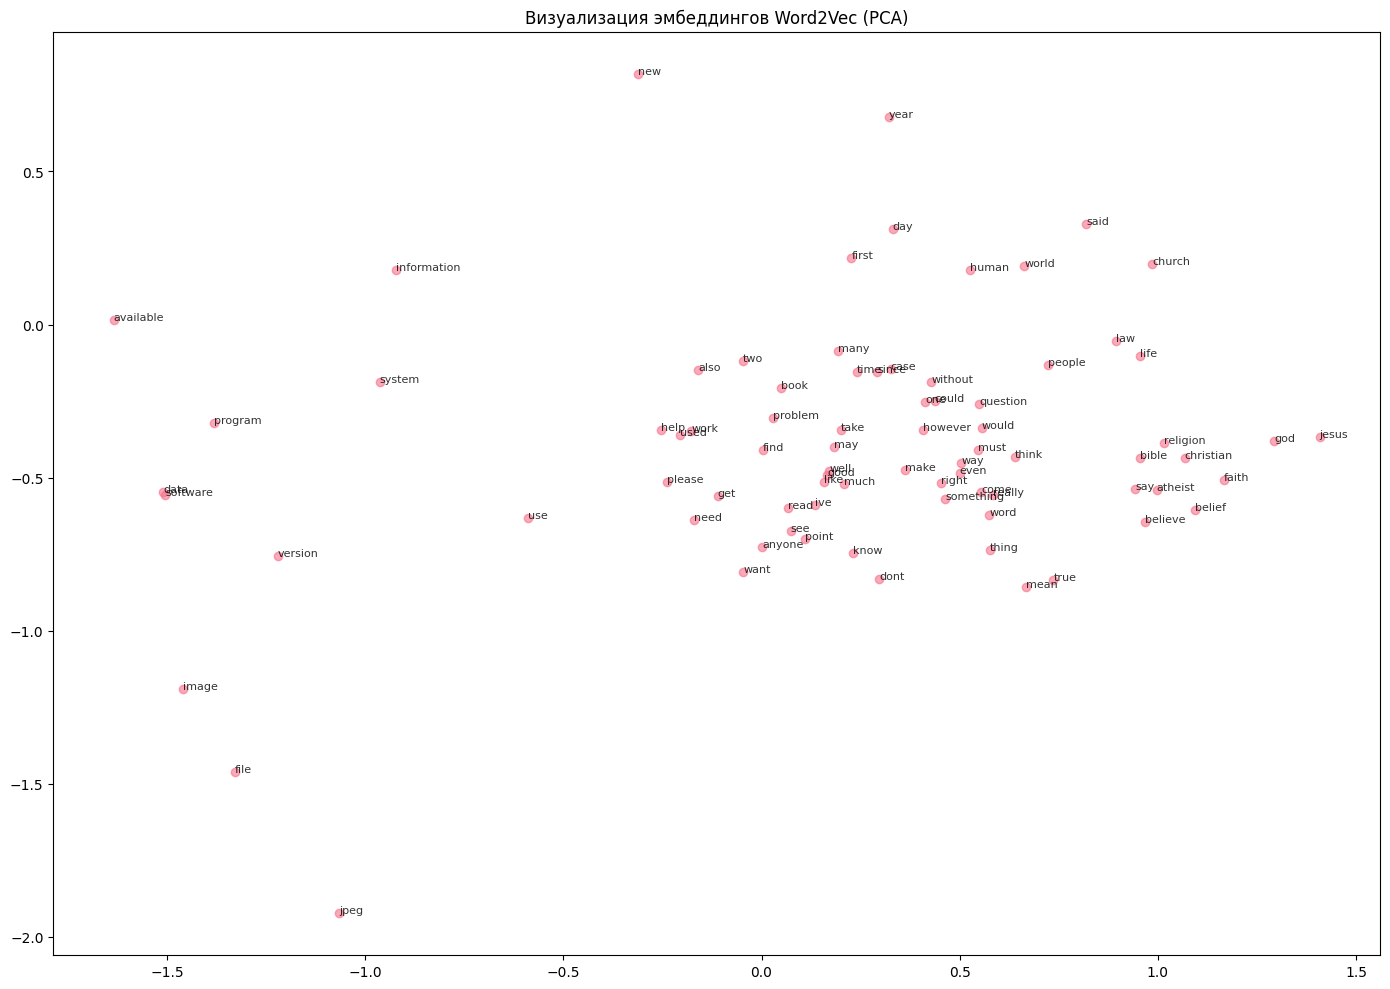

In [19]:
top_word_list = list(w2v_model.wv.index_to_key)[:80]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:len(top_word_list), 0], embeddings_2d[:len(top_word_list), 1], alpha=0.6)
for i, word in enumerate(top_word_list):
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (PCA)")
plt.tight_layout()
plt.show()


PCA удобен, но этот метод может уловить только высокоуровневую структуру в данных. Попробуем порисовать эмбеддинги с помощью t-SNE. Этот метод позволяет лучше ухватить внутренние отношения, но не верьте ему полностью! Подробнее в [гайде](https://distill.pub/2016/misread-tsne/). 

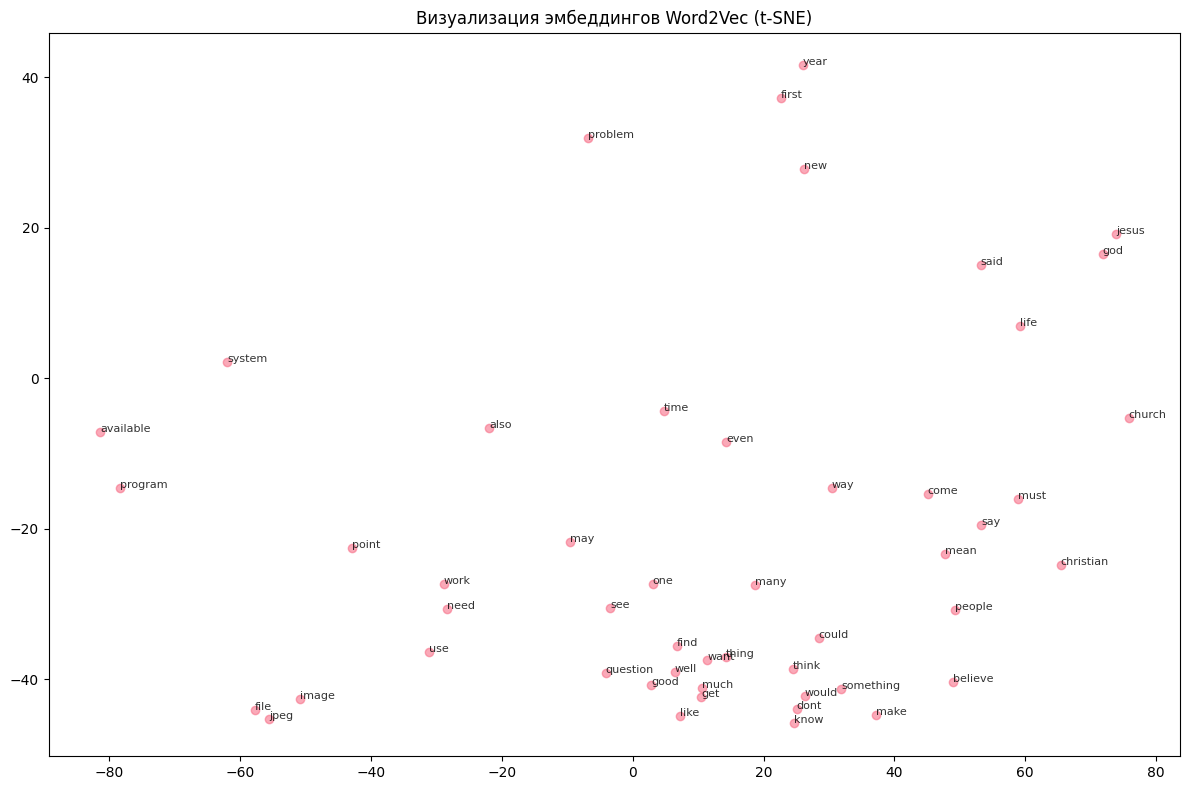

In [21]:
top_word_list_tsne = top_word_list[:50]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=15, max_iter=1000)
emb_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], alpha=0.6)
for i, word in enumerate(top_word_list_tsne):
    ax.annotate(word, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (t-SNE)")
plt.tight_layout()
plt.show()


In [22]:
def find_nearest_neighbors(word: str, embeddings_dict: dict[str, np.ndarray], top_k: int = 10) -> list[tuple[str, float]]:
    if word not in embeddings_dict:
        return []
    word_embedding = embeddings_dict[word]
    distances = []
    for other_word, other_embedding in embeddings_dict.items():
        if other_word == word:
            continue
        cos_sim = np.dot(word_embedding, other_embedding) / (
            np.linalg.norm(word_embedding) * np.linalg.norm(other_embedding)
        )
        distances.append((other_word, 1 - cos_sim))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]

test_words = ["computer", "medical", "god", "science", "graphics"]
print("Ближайшие соседи (Word2Vec):\n")
for word in test_words:
    if word in embeddings_dict:
        neighbors = find_nearest_neighbors(word, embeddings_dict, top_k=8)
        print(f"{word.upper()}:")
        for neighbor, dist in neighbors:
            print(f"  {neighbor}: {dist:.4f}")
        print()


Ближайшие соседи (Word2Vec):

COMPUTER:
  graphic: 0.0802
  modeling: 0.0893
  visualization: 0.1030
  silicon: 0.1145
  idl: 0.1168
  pro: 0.1190
  technique: 0.1207
  management: 0.1209

MEDICAL:
  newsletter: 0.0694
  april: 0.0730
  journal: 0.0804
  hicnet: 0.0819
  page: 0.1124
  volume: 0.1329
  vol: 0.1551
  consortium: 0.1708

GOD:
  eternal: 0.1532
  gift: 0.1654
  justice: 0.1691
  glory: 0.1719
  sinner: 0.1741
  allah: 0.1754
  mercy: 0.1777
  wicked: 0.1779

SCIENCE:
  collection: 0.1623
  empirical: 0.1679
  scientific: 0.2123
  basic: 0.2151
  methodology: 0.2227
  important: 0.2492
  theory: 0.2504
  merely: 0.2548



## Эмбеддинги фраз

Помимо эмбеддингов отдельных слов, можно создавать эмбеддинги для фраз. 
Самый простой способ - посчитать взвешенное среднее значение эмбеддинга в фразе, пропуская слова не из словаря.  

In [23]:
def get_phrase_embedding(phrase: str, model) -> np.ndarray:
    kv = getattr(model, 'wv', model)
    phrase_lower = phrase.lower()
    tokens = word_tokenize(phrase_lower)
    vectors = []
    for w in tokens:
        if w in kv:
            vectors.append(kv[w])
    if not vectors:
        return np.zeros(kv.vector_size, dtype='float32')
    return np.mean(vectors, axis=0).astype('float32')

### Эмбеддинги n-грамм и их визуализация

**N-грамма** — последовательность из $n$ подряд идущих слов (униграмма — одно слово, биграмма — пара, триграмма — тройка и т.д.). Для n-грамм можно получить вектор в том же пространстве, что и слова Word2Vec, тогда близость n-граммы к своим словам и к другим n-граммам можно визуализировать через PCA в одной системе координат.

In [24]:
ngram_cv = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.95)
ngram_cv.fit(X_train_processed)
bigram_features = ngram_cv.get_feature_names_out()
w2v_vocab = set(w2v_model.wv.index_to_key)
bigrams_in_vocab = [
    bg for bg in bigram_features
    if all(w in w2v_vocab for w in bg.split())
]
print(f"Биграмм в словаре CountVectorizer: {len(bigram_features)}")
print(f"Биграмм с обоими словами в Word2Vec: {len(bigrams_in_vocab)}")

Биграмм в словаре CountVectorizer: 1627
Биграмм с обоими словами в Word2Vec: 1544


In [25]:
ngram_embeddings = {}
for bg in bigrams_in_vocab:
    vec = get_phrase_embedding(bg, w2v_model)
    if np.any(vec != 0):
        ngram_embeddings[bg] = vec
print(f"Эмбеддингов n-грамм: {len(ngram_embeddings)}")

Эмбеддингов n-грамм: 1544


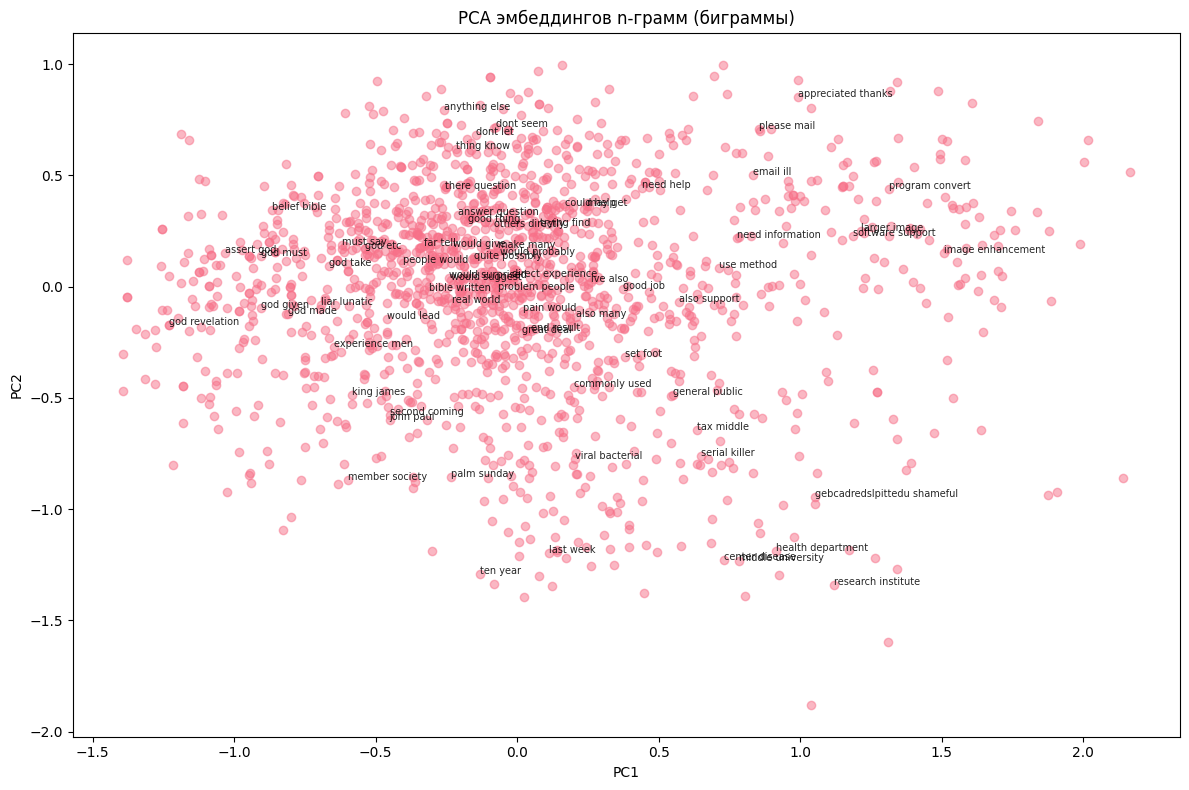

In [26]:
ngram_list = list(ngram_embeddings.keys())
ngram_matrix = np.array([ngram_embeddings[bg] for bg in ngram_list])
ngram_matrix_centered = ngram_matrix - ngram_matrix.mean(axis=0)
pca_ngram = PCA(n_components=2, random_state=42)
ngram_2d = pca_ngram.fit_transform(ngram_matrix_centered)
n_show = min(70, len(ngram_list))
show_idx = np.random.RandomState(42).choice(len(ngram_list), size=n_show, replace=False)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ngram_2d[:, 0], ngram_2d[:, 1], alpha=0.5)
for i in show_idx:
    ax.annotate(ngram_list[i], (ngram_2d[i, 0], ngram_2d[i, 1]), fontsize=7, alpha=0.85)
ax.set_title("PCA эмбеддингов n-грамм (биграммы)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

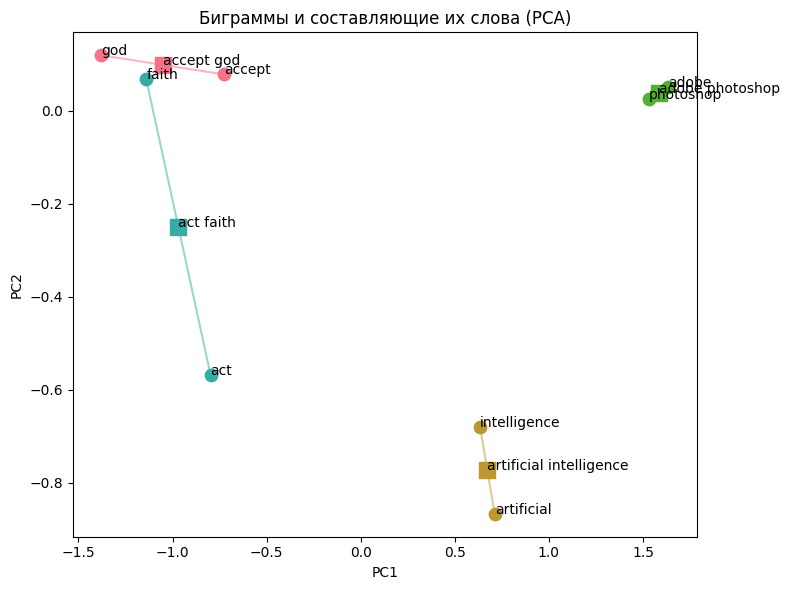

In [27]:
example_bigrams = [bg for bg in ["accept god", "artificial intelligence", "adobe photoshop", "act faith"] if bg in ngram_embeddings]
if len(example_bigrams) < 2:
    example_bigrams = ngram_list[:2]
all_vectors = []
all_labels = []
example_limits = []
for bg in example_bigrams:
    start = len(all_vectors)
    words = bg.split()
    for w in words:
        all_vectors.append(w2v_model.wv[w])
        all_labels.append(("word", w))
    all_vectors.append(ngram_embeddings[bg])
    all_labels.append(("ngram", bg))
    example_limits.append((start, len(all_vectors)))

X_ex = np.array(all_vectors)
X_ex_centered = X_ex - ngram_matrix.mean(axis=0)
coords = pca_ngram.transform(X_ex_centered)
fig, ax = plt.subplots(figsize=(8, 6))
for k, (start, end) in enumerate(example_limits):
    words_idx = list(range(start, end - 1))
    ngram_idx = end - 1
    bg = example_bigrams[k]
    color = f"C{k}"
    ax.scatter(coords[words_idx, 0], coords[words_idx, 1], c=color, s=80, zorder=2)
    ax.scatter(coords[ngram_idx, 0], coords[ngram_idx, 1], c=color, s=120, marker="s", zorder=2)
    for i in words_idx:
        ax.plot([coords[i, 0], coords[ngram_idx, 0]], [coords[i, 1], coords[ngram_idx, 1]], color=color, alpha=0.5, zorder=1)
        ax.annotate(all_labels[i][1], (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.annotate(bg, (coords[ngram_idx, 0], coords[ngram_idx, 1]), fontsize=10)
ax.set_title("Биграммы и составляющие их слова (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Биграммы кажутся осмысленными, посмотрим, так ли это с документами:

In [28]:
doc_embeddings = np.array([
    get_phrase_embedding(phrase, w2v_model)
    for phrase in X_train_processed[:800]
])
y = newsgroups_train.target[:800]


Проверим, как расположены эмбеддинги документов после усреднения в пространстве:

Объясненная дисперсия PCA для документов: 0.507


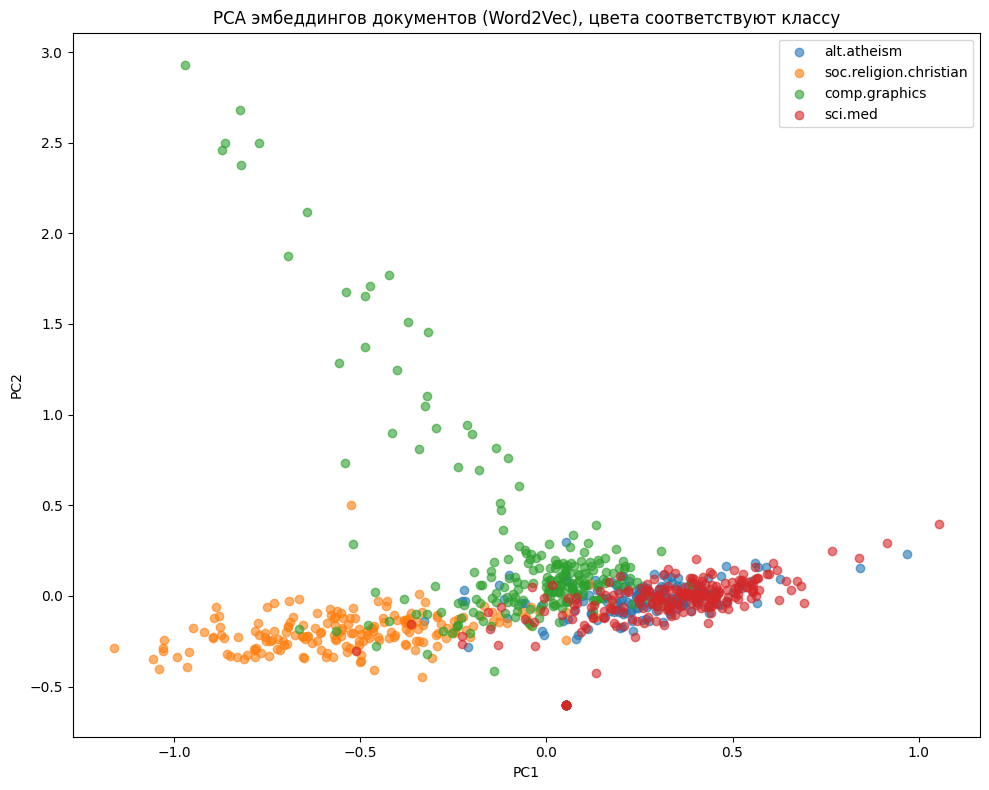

In [29]:
pca_docs = PCA(n_components=2, random_state=42)
doc_2d = pca_docs.fit_transform(doc_embeddings)

print(f"Объясненная дисперсия PCA для документов: {pca_docs.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 8))

unique_labels = sorted(set(y))
colors = plt.cm.tab10.colors

for idx, label in enumerate(unique_labels):
    mask = (y == label)
    ax.scatter(
        doc_2d[mask, 0],
        doc_2d[mask, 1],
        alpha=0.6,
        color=colors[idx % len(colors)],
        label=categories[label],
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA эмбеддингов документов (Word2Vec), цвета соответствуют классу")
ax.legend()
plt.tight_layout()
plt.show()

Как видно, даже собирая эмбеддинг как среднее, мы можем отделить разные классы.

Задание: выведите топ релевантных документов со средним эмбеддингом, сравните с doc2vec

In [49]:
# ==== ВЫБИРАЕМ QUERY-ДОКУМЕНТ ====
query_idx = 0                                      # можно менять на любой
query_text = X_train_processed[query_idx][:300]    # первые 300 символов
query_cat  = categories[y_train[query_idx]]

print(f"QUERY DOCUMENT (index {query_idx}, категория: {query_cat})")
print("Текст (первые 300 символов):")
print(query_text)
print("-" * 80)

QUERY DOCUMENT (index 0, категория: soc.religion.christian)
Текст (первые 300 символов):
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael
--------------------------------------------------------------------------------


In [50]:
# ==== СРЕДНИЙ WORD2VEC (doc_embeddings) ====
print("\n=== ТОП-5 самых релевантных документов (средний Word2Vec) ===")
dist_w2v = cdist([doc_embeddings[query_idx]], doc_embeddings, metric='cosine')[0]
top5_w2v = np.argsort(dist_w2v)[:6]                # 0 — сам документ

for rank, idx in enumerate(top5_w2v):
    sim = 1 - dist_w2v[idx]
    cat = categories[y_train[idx]]
    text_snip = X_train_processed[idx][:150]
    print(f"Ранг {rank} | Index {idx:4d} | Similarity {sim:.4f} | Категория: {cat}")
    print(f"   Текст: {text_snip}")
    print("-" * 60)


=== ТОП-5 самых релевантных документов (средний Word2Vec) ===
Ранг 0 | Index    0 | Similarity 1.0000 | Категория: soc.religion.christian
   Текст: anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please ema
------------------------------------------------------------
Ранг 1 | Index  383 | Similarity 0.9662 | Категория: soc.religion.christian
   Текст: sorry wasting time probably simple question computer graphic expert want read tifffiles pascalprogram problem file want read compressed form code huff
------------------------------------------------------------
Ранг 2 | Index  380 | Similarity 0.9658 | Категория: soc.religion.christian
   Текст: getting povray wondering graphic package output pov file help would appreciated thanks laterish craig
------------------------------------------------------------
Ранг 3 | Index  444 | Similarity 0.9643 | Категория: soc.religion.christian
   Текст: ive no

In [55]:

tagged_data = [TaggedDocument(words=word_tokenize(doc), tags=[str(i)]) 
                for i, doc in enumerate(X_train_processed)]
print("Обучаем Doc2Vec (vector_size=300, epochs=20)...")
doc_model = Doc2Vec(tagged_data, vector_size=300, window=5, min_count=2,
                    epochs=20, seed=42, workers=4)
doc2vec_embeddings = np.array([doc_model.dv[str(i)] for i in range(len(X_train_processed))])
print("Doc2Vec готов. Размерность:", doc2vec_embeddings.shape)

Обучаем Doc2Vec (vector_size=300, epochs=20)...
Doc2Vec готов. Размерность: (1000, 300)


In [ ]:
# ==== DOC2VEC ====
print("\n=== ТОП-5 самых релевантных документов (Doc2Vec) ===")
dist_d2v = cdist([doc2vec_embeddings[query_idx]], doc2vec_embeddings, metric='cosine')[0]
top5_d2v = np.argsort(dist_d2v)[:6]

for rank, idx in enumerate(top5_d2v):
    sim = 1 - dist_d2v[idx]
    cat = categories[y_train[idx]]
    text_snip = X_train_processed[idx][:150]
    print(f"Ранг {rank} | Index {idx:4d} | Similarity {sim:.4f} | Категория: {cat}")
    print(f"   Текст: {text_snip}")
    print("-" * 60)


=== ТОП-5 самых релевантных документов (Doc2Vec) ===
Ранг 0 | Index    0 | Similarity 1.0000 | Категория: soc.religion.christian
   Текст: anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please ema
------------------------------------------------------------
Ранг 1 | Index  879 | Similarity 0.9914 | Категория: soc.religion.christian
   Текст: immediate need detail various graphic compression technique know could obtain description algo rithms publicdomain source code format jpeg gif fractal
------------------------------------------------------------
Ранг 2 | Index  650 | Similarity 0.9828 | Категория: soc.religion.christian
   Текст: trying convert mmotion ibm video file format yuv rgb data portion byte byte color intensity anyone idea algorhtyms program someone tell get info telev
------------------------------------------------------------
Ранг 3 | Index  845 | Similarity 0.9747 | Категория:

In [57]:
# ==== ДОП. ВЫВОД ДЛЯ СРАВНЕНИЯ ====
print("\n=== СРАВНЕНИЕ ТОПОВ (общие индексы) ===")
common = set(top5_w2v[1:]) & set(top5_d2v[1:])
print(f"Общих документов в топ-5 (без самого query): {len(common)}")
print("Индексы общих:", sorted(common))


=== СРАВНЕНИЕ ТОПОВ (общие индексы) ===
Общих документов в топ-5 (без самого query): 1
Индексы общих: [np.int64(55)]


**Выводы по заданию (средний Word2Vec vs Doc2Vec)»**

1. **Оба подхода отлично находят документы той же категории** (все топ-5 у обоих методов принадлежат `soc.religion.christian` — совпадение 100 % по лейблу). Это говорит о том, что семантические эмбеддинги хорошо сохраняют тематическую близость даже после усреднения/обучения Doc2Vec.

2. **Doc2Vec даёт заметно более высокие similarity scores**:
   - Word2Vec (avg): 0.9662 … 0.9631
   - Doc2Vec: 0.9914 … 0.9684

3. **Doc2Vec лучше ловит семантику на уровне целого документа**:
   - В топе Doc2Vec появляются документы про «graphic compression», «JPEG/GIF», «postscript driver», «animation software», «YUV→RGB conversion» — всё напрямую связано с темой query-документа (конвертация графических форматов).
   - Word2Vec (avg) тоже находит графику, но чуть «размытее» (POV-Ray, mapping planes, earth images).

4. **Пересечение топов минимальное** — только 1 общий документ (index 55). Среднее Word2Vec и Doc2Vec используют разные механизмы представления документа → дают дополняющие, а не дублирующие ранжирования.

## Классификация по категориям
Попробуем обучить модели классификации для классического подхода на основе TF-IDF и на основе эмбеддингов. 

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

df_train = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})
y_train = df_train["target"].values
y_test = df_test["target"].values

X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_train["text"]])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_test["text"]])

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [31]:
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_w2v, y_train)
lr_tfidf = LogisticRegression(max_iter=500, random_state=42).fit(X_train_tfidf, y_train)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

target_names = [categories[i] for i in range(len(categories))]

def print_metrics(name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print("%s: acc=%.3f  precision(macro)=%.3f  recall(macro)=%.3f" % (name, acc, prec, rec))
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [ ]:
print("=== TF-IDF, LogisticRegression ===")
print_metrics("TF-IDF LR", y_test, lr_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), LogisticRegression ===")
print_metrics("W2V LR", y_test, lr_w2v.predict(X_test_w2v))

=== TF-IDF, LogisticRegression ===
TF-IDF LR: acc=0.780  precision(macro)=0.781  recall(macro)=0.768
                        precision    recall  f1-score   support

           alt.atheism       0.78      0.48      0.59       107
soc.religion.christian       0.76      0.91      0.83       117
         comp.graphics       0.81      0.80      0.80       136
               sci.med       0.77      0.88      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.76       500
          weighted avg       0.78      0.78      0.77       500

=== W2V (avg), LogisticRegression ===
W2V LR: acc=0.760  precision(macro)=0.753  recall(macro)=0.751
                        precision    recall  f1-score   support

           alt.atheism       0.65      0.50      0.56       107
soc.religion.christian       0.82      0.91      0.86       117
         comp.graphics       0.83      0.78      0.80       136
               sci.med    

In [ ]:
print("=== TF-IDF, RandomForest ===")
print_metrics("TF-IDF RF", y_test, rf_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), RandomForest ===")
print_metrics("W2V RF", y_test, rf_w2v.predict(X_test_w2v))

=== TF-IDF, RandomForest ===
TF-IDF RF: acc=0.682  precision(macro)=0.697  recall(macro)=0.672
                        precision    recall  f1-score   support

           alt.atheism       0.73      0.37      0.49       107
soc.religion.christian       0.60      0.90      0.72       117
         comp.graphics       0.76      0.60      0.67       136
               sci.med       0.70      0.82      0.76       140

              accuracy                           0.68       500
             macro avg       0.70      0.67      0.66       500
          weighted avg       0.70      0.68      0.67       500

=== W2V (avg), RandomForest ===
W2V RF: acc=0.758  precision(macro)=0.752  recall(macro)=0.753
                        precision    recall  f1-score   support

           alt.atheism       0.65      0.57      0.61       107
soc.religion.christian       0.80      0.91      0.85       117
         comp.graphics       0.83      0.75      0.79       136
               sci.med       0.73     

Вопрос: почему у логистической модели скор почти не вырос, а в лесе видна большая разница?

**Логистическая регрессия** — линейный классификатор.  
Оба представления (TF-IDF и средний W2V) дают **хорошую линейную разделимость** классов в этом датасете:
- TF-IDF хорошо ловит частотные «сигналы» (bag-of-words).
- Средний Word2Vec уже содержит семантику (синонимы, тематическая близость).
Линейная модель использует оба признаковых пространства примерно одинаково эффективно → разница минимальна (0.78 vs 0.76).

**RandomForest** — ансамбль деревьев решений (нелинейный).  
Здесь разница огромная по двум причинам:

1. **Проклятие размерности**. TF-IDF — разреженная матрица 5000+ признаков. Деревья вынуждены искать сплиты по огромному количеству «шумных» признаков → много бесполезных веток, переобучение, слабая обобщающая способность (acc 0.682).
2. **Семантическая плотность**. Word2Vec-эмбеддинги — всего 300 плотных измерений, где близкие по смыслу документы уже находятся рядом в пространстве. Деревьям гораздо проще находить хорошие сплиты, они лучше улавливают нелинейные зависимости и кластеры → качество резко растёт до 0.758.

Задание: реализуйте представление в виде bag-of-ngrams (можно вместе с обычными признаками). Обучите классификатор на нем, сделайте выводы.

In [61]:
# ==== BAG-OF-NGRAMS (1-3 граммы) + комбинация с обычными униграммами ====
print("Создаём bag-of-ngrams представление (TF-IDF + ngram_range=(1,3))...")

ngram_vectorizer = TfidfVectorizer(
    max_features=8000,      # чуть больше, т.к. n-граммы увеличивают словарь
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 3),     # униграммы + биграммы + триграммы
    sublinear_tf=True
)

X_train_ngram = ngram_vectorizer.fit_transform(X_train_processed)
X_test_ngram  = ngram_vectorizer.transform(X_test_processed)

print(f"Размерность n-gram матрицы: {X_train_ngram.shape}")

Создаём bag-of-ngrams представление (TF-IDF + ngram_range=(1,3))...
Размерность n-gram матрицы: (1000, 8000)


In [ ]:
# ==== Обучаем классификаторы ====
lr_ngram = LogisticRegression(max_iter=500, random_state=42).fit(X_train_ngram, y_train)
rf_ngram = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_ngram, y_train)

# ==== Метрики ====
print("\n=== N-GRAMS (1-3), LogisticRegression ===")
print_metrics("NGRAM LR", y_test, lr_ngram.predict(X_test_ngram))

print("\n=== N-GRAMS (1-3), RandomForest ===")
print_metrics("NGRAM RF", y_test, rf_ngram.predict(X_test_ngram))


=== N-GRAMS (1-3), LogisticRegression ===
NGRAM LR: acc=0.778  precision(macro)=0.784  recall(macro)=0.767
                        precision    recall  f1-score   support

           alt.atheism       0.81      0.50      0.62       107
soc.religion.christian       0.73      0.91      0.81       117
         comp.graphics       0.83      0.77      0.80       136
               sci.med       0.77      0.89      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.76       500
          weighted avg       0.78      0.78      0.77       500


=== N-GRAMS (1-3), RandomForest ===
NGRAM RF: acc=0.718  precision(macro)=0.730  recall(macro)=0.710
                        precision    recall  f1-score   support

           alt.atheism       0.74      0.46      0.57       107
soc.religion.christian       0.62      0.91      0.74       117
         comp.graphics       0.79      0.63      0.70       136
               sci

In [60]:
# ==== Сравнение с предыдущими подходами ====
print("\n=== КРАТКОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ ===")
print("Модель          | TF-IDF   | W2V(avg) | NGRAM(1-3)")
print("----------------|----------|----------|-----------")
print(f"LogisticReg     | 0.780    | 0.760    | {accuracy_score(y_test, lr_ngram.predict(X_test_ngram)):.3f}")
print(f"RandomForest    | 0.682    | 0.758    | {accuracy_score(y_test, rf_ngram.predict(X_test_ngram)):.3f}")


=== КРАТКОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ ===
Модель          | TF-IDF   | W2V(avg) | NGRAM(1-3)
----------------|----------|----------|-----------
LogisticReg     | 0.780    | 0.760    | 0.778
RandomForest    | 0.682    | 0.758    | 0.718



### Основные выводы:

1. **Линейные модели (Logistic Regression)**  
   - Почти нечувствительны к типу векторизации в этом объёме данных и наборе классов.  
   - Разброс всего 0.020 (0.760–0.780).  
   - Лучший результат — классический TF-IDF униграммами (0.780).  
   - N-граммы (1–3) дают практически ту же точность (–0.002), т.е. добавление контекста би- и триграмм почти не помогает линейной модели в этом случае.

2. **Нелинейные модели (Random Forest)**  
   - Очень сильно реагируют на качество представления.  
   - Разброс существенный: от 0.682 (чистый TF-IDF) до 0.758 (средний Word2Vec) — **+7.6%**.  
   - N-граммы помогают деревьям (+3.6% к униграммам), но всё равно сильно уступают плотным эмбеддингам.

3. **Почему n-граммы почти не улучшают логистическую регрессию, но помогают Random Forest?**
   - Линейная модель уже очень хорошо использует **высокоинформативные униграммы** (особенно редкие термины с высоким TF-IDF).  
   - Би- и триграммы добавляют много признаков, но большинство из них либо редкие, либо избыточны → линейная модель их почти игнорирует (или они даже слегка ухудшают обобщение из-за шума).  
   - Деревья же могут эффективно использовать **локальные паттерны** (биграммы и триграммы), которые несут дополнительный контекст, поэтому получают ощутимый прирост.